# Federated Learning - Motor Imagery BCI2014-001

Strategies: FedAvg, FedProx, SCAFFOLD, FedBS, FedNova

Pure-Python federation (no Flower/gRPC). SCAFFOLD bug fixed:
control variates use `model.parameters()` shapes, not `state_dict()`.

In [39]:
# 1. Install
import subprocess, sys
def pip(*a): subprocess.check_call([sys.executable,'-m','pip','install','-q']+list(a))
pip('moabb','mne','scikit-learn','torch','tqdm','matplotlib','seaborn')
print('Install complete')

Install complete


In [40]:
# 2. Imports
import warnings, copy, random
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import moabb
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
moabb.set_log_level('WARNING')
torch.manual_seed(42); np.random.seed(42); random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [41]:
# 3. Config
CFG = dict(
    sfreq=250, tmin=0.0, tmax=4.0, fmin=4.0, fmax=40.0,
    n_classes=4, n_channels=22,
    local_epochs=5, batch_size=32, lr=1e-3, wd=1e-4,
    num_rounds=20,
    proximal_mu=0.01,
    scaffold_lr=1e-3,
)
print('Config ready')

Config ready


## 4. Load Dataset via MOABB

In [42]:
# 4. Load MOABB
def load_data(cfg):
    print('Loading BNCI2014_001 ...')
    dataset  = BNCI2014_001()
    paradigm = MotorImagery(
        n_classes=cfg['n_classes'], fmin=cfg['fmin'], fmax=cfg['fmax'],
        tmin=cfg['tmin'], tmax=cfg['tmax'], resample=cfg['sfreq'])
    X, y, meta = paradigm.get_data(dataset=dataset)
    le = LabelEncoder(); y_enc = le.fit_transform(y)
    print(f'Shape: {X.shape}  Classes: {list(le.classes_)}')
    cdata = {}
    for cid, subj in enumerate(sorted(meta['subject'].unique())):
        mask = (meta['subject'] == subj).values
        Xs, ys = X[mask], y_enc[mask]
        Xtr,Xte,ytr,yte = train_test_split(Xs,ys,test_size=0.2,stratify=ys,random_state=42)
        cdata[cid] = dict(X_train=Xtr.astype(np.float32), X_test=Xte.astype(np.float32),
                          y_train=ytr.astype(np.int64),   y_test=yte.astype(np.int64))
        print(f'  Client {cid:02d} (sub={subj}): train={len(ytr)}  test={len(yte)}')
    return cdata, X.shape[-1]

client_data, N_TIMES = load_data(CFG)
CFG['n_times'] = N_TIMES
N_CLIENTS = len(client_data)
print(f'Clients: {N_CLIENTS}  T: {N_TIMES}')

2026-03-03 10:20:33,440 WARNING MainThread moabb.paradigms.motor_imagery Choosing from all possible events


Loading BNCI2014_001 ...
Shape: (5184, 22, 1001)  Classes: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
  Client 00 (sub=1): train=460  test=116
  Client 01 (sub=2): train=460  test=116
  Client 02 (sub=3): train=460  test=116
  Client 03 (sub=4): train=460  test=116
  Client 04 (sub=5): train=460  test=116
  Client 05 (sub=6): train=460  test=116
  Client 06 (sub=7): train=460  test=116
  Client 07 (sub=8): train=460  test=116
  Client 08 (sub=9): train=460  test=116
Clients: 9  T: 1001


## 5. EEGNet

In [43]:
# 5. EEGNet
class EEGNet(nn.Module):
    def __init__(self, n_classes=4, n_channels=22, n_times=1001, F1=8, D=2, F2=16, dp=0.5):
        super().__init__()
        self.temporal = nn.Sequential(
            nn.Conv2d(1, F1, (1,64), padding=(0,32), bias=False),
            nn.BatchNorm2d(F1))
        self.spatial = nn.Sequential(
            nn.Conv2d(F1, D*F1, (n_channels,1), groups=F1, bias=False),
            nn.BatchNorm2d(D*F1), nn.ELU(), nn.AvgPool2d((1,4)), nn.Dropout(dp))
        self.separable = nn.Sequential(
            nn.Conv2d(D*F1, D*F1, (1,16), padding=(0,8), groups=D*F1, bias=False),
            nn.Conv2d(D*F1, F2, (1,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(), nn.AvgPool2d((1,8)), nn.Dropout(dp))
        with torch.no_grad():
            x = torch.zeros(1,1,n_channels,n_times)
            x = self.separable(self.spatial(self.temporal(x)))
            self._flat = int(np.prod(x.shape[1:]))
        self.fc = nn.Linear(self._flat, n_classes)
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.separable(self.spatial(self.temporal(x)))
        return self.fc(x.view(x.size(0),-1))

_m = EEGNet(CFG['n_classes'], CFG['n_channels'], CFG['n_times']).to(DEVICE)
print('Output:', _m(torch.randn(4,CFG['n_channels'],CFG['n_times']).to(DEVICE)).shape)
print('Params:', sum(p.numel() for p in _m.parameters() if p.requires_grad))

Output: torch.Size([4, 4])
Params: 3444


## 6. Utilities

> **Why two weight helpers?**  
> `state_dict()` contains BatchNorm *buffers* (`running_mean`, `running_var`,
> `num_batches_tracked`) in addition to learnable params.  
> `model.parameters()` contains **only** the learnable params.  
> SCAFFOLD's gradient correction loop zips with `model.parameters()`,
> so the control variates **must** be built from `zero_param_arrays()`
> (which mirrors `model.parameters()`), never from `get_weights()`
> (which mirrors `state_dict()`). Mixing them caused the previous
> `RuntimeError: broadcast shape [16,1,22,1] vs [16,1,22,8]`.

In [44]:
# 6. Utilities
# -------------------------------------------------------------------
# TWO separate helpers to avoid the SCAFFOLD broadcast shape bug:
#
#   get_weights / set_weights  -- full state_dict (params + BN buffers)
#                                  used for FL weight AGGREGATION
#
#   get_param_arrays           -- learnable params ONLY (model.parameters())
#   zero_param_arrays          -- zero arrays matching model.parameters() shapes
#                                  used for SCAFFOLD control variates
#
# Mixing these was the cause of:
#   RuntimeError: output [16,1,22,1] doesn't match broadcast [16,1,22,8]
# -------------------------------------------------------------------
def make_loader(X, y, bs, shuffle=True, balanced=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    sampler = None
    if balanced:
        counts  = np.bincount(y)
        weights = torch.tensor(1.0/counts[y], dtype=torch.float32)
        sampler = WeightedRandomSampler(weights, len(y), replacement=True)
        shuffle = False
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, sampler=sampler)

def get_weights(m):  # full state_dict
    return [v.cpu().numpy().copy() for v in m.state_dict().values()]
def set_weights(m, w):
    m.load_state_dict({k: torch.tensor(v) for k,v in zip(m.state_dict(),w)}, strict=True)

def get_param_arrays(m):  # learnable params only
    return [p.detach().cpu().numpy().copy() for p in m.parameters()]
def zero_param_arrays(m):
    return [np.zeros_like(p.detach().cpu().numpy()) for p in m.parameters()]

def fedavg_agg(updates):
    total = sum(n for n,_ in updates)
    return [sum(n*w[i] for n,w in updates)/total for i in range(len(updates[0][1]))]

def new_model(): return EEGNet(CFG['n_classes'], CFG['n_channels'], CFG['n_times'])

print('Utilities ready')
ref = new_model()
print(f'  state_dict keys : {len(list(ref.state_dict()))}')
print(f'  parameter count : {len(list(ref.parameters()))}')
print('  diff = BN running_mean / running_var / num_batches_tracked')

Utilities ready
  state_dict keys : 21
  parameter count : 12
  diff = BN running_mean / running_var / num_batches_tracked


## 7. Local Training & Evaluation

In [45]:
# 7. Local train & eval
def train_local(model, loader, epochs, device,
                mu=0.0, global_w=None, c_i=None, c_g=None):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['wd'])
    ce  = nn.CrossEntropyLoss()
    ci_t = cg_t = None
    if c_i is not None:
        # c_i and c_g are built from model.parameters() so shapes are guaranteed
        ci_t = [torch.tensor(v, device=device) for v in c_i]
        cg_t = [torch.tensor(v, device=device) for v in c_g]
    tot_loss = tot_ok = tot_n = 0
    for _ in range(epochs):
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            out  = model(Xb)
            loss = ce(out, yb)
            if mu > 0 and global_w is not None:
                prox = sum((p-g.to(device)).pow(2).sum()
                           for p,g in zip(model.parameters(), global_w))
                loss = loss + (mu/2)*prox
            loss.backward()
            if ci_t is not None:
                for p, ci, cg in zip(model.parameters(), ci_t, cg_t):
                    if p.grad is not None:
                        p.grad.data.add_(cg - ci)
            opt.step()
            tot_ok   += (out.argmax(1)==yb).sum().item()
            tot_loss += loss.item()*Xb.size(0)
            tot_n    += Xb.size(0)
    return dict(loss=tot_loss/max(tot_n,1), accuracy=tot_ok/max(tot_n,1),
                n_samples=max(tot_n//epochs,1), local_steps=epochs*len(loader))

@torch.no_grad()
def eval_model(model, loader, device):
    model.eval()
    ce = nn.CrossEntropyLoss()
    tot_loss=0.0; preds=[]; labels=[]
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        out = model(Xb)
        tot_loss += ce(out,yb).item()*Xb.size(0)
        preds.extend(out.argmax(1).cpu().tolist())
        labels.extend(yb.cpu().tolist())
    return tot_loss/max(len(labels),1), accuracy_score(labels, preds)

print('Train/eval ready')

Train/eval ready


## 8. Per-Client State

In [46]:
# 8. Client state
class ClientState:
    def __init__(self, cid, data, balanced=False):
        self.cid  = cid
        self.n_tr = len(data['y_train'])
        self.n_te = len(data['y_test'])
        self.tr   = make_loader(data['X_train'], data['y_train'],
                                CFG['batch_size'], shuffle=not balanced, balanced=balanced)
        self.te   = make_loader(data['X_test'], data['y_test'],
                                CFG['batch_size'], shuffle=False)
        self.c_i: Optional[List[np.ndarray]] = None  # SCAFFOLD only

def build_clients(balanced=False):
    return {cid: ClientState(cid, client_data[cid], balanced=balanced)
            for cid in range(N_CLIENTS)}

print('Client state ready')

Client state ready


## 9. Federated Learning Strategies

In [47]:
# 9. FL strategies
def eval_all(gw, clients):
    m = new_model().to(DEVICE); set_weights(m, gw)
    accs = []; ns = []
    for cs in clients.values():
        _, a = eval_model(m, cs.te, DEVICE)
        accs.append(a); ns.append(cs.n_te)
    return sum(n*a for n,a in zip(ns,accs))/sum(ns)

def _pr(rnd, total, acc):
    print(f'  Round {rnd:3d}/{total}  acc={acc:.4f}', end='\r')

# ── FedAvg ────────────────────────────────────────────────────────────────
def run_fedavg(clients, rounds):
    gw = get_weights(new_model()); hist = []
    for r in range(1, rounds+1):
        ups = []
        for cs in clients.values():
            m = new_model().to(DEVICE); set_weights(m, gw)
            train_local(m, cs.tr, CFG['local_epochs'], DEVICE)
            ups.append((cs.n_tr, get_weights(m)))
        gw = fedavg_agg(ups)
        acc = eval_all(gw, clients); hist.append((r,acc)); _pr(r,rounds,acc)
    print(); return gw, hist

# ── FedProx ───────────────────────────────────────────────────────────────
def run_fedprox(clients, rounds):
    gw = get_weights(new_model()); hist = []
    for r in range(1, rounds+1):
        ups = []
        for cs in clients.values():
            m = new_model().to(DEVICE); set_weights(m, gw)
            gwt = [p.clone().detach() for p in m.parameters()]
            train_local(m, cs.tr, CFG['local_epochs'], DEVICE,
                        mu=CFG['proximal_mu'], global_w=gwt)
            ups.append((cs.n_tr, get_weights(m)))
        gw = fedavg_agg(ups)
        acc = eval_all(gw, clients); hist.append((r,acc)); _pr(r,rounds,acc)
    print(); return gw, hist

# ── SCAFFOLD ──────────────────────────────────────────────────────────────
# FIX: c_i and c_global are built with zero_param_arrays() which uses
# model.parameters() shapes -- NOT state_dict() which includes BN buffers.
# The gradient correction loop zips with model.parameters() so shapes match.
def run_scaffold(clients, rounds):
    gw       = get_weights(new_model())
    c_global = zero_param_arrays(new_model())  # len == len(list(model.parameters()))
    for cs in clients.values():
        cs.c_i = zero_param_arrays(new_model())
    hist = []
    for r in range(1, rounds+1):
        ups = []; dc = zero_param_arrays(new_model())
        for cs in clients.values():
            m = new_model().to(DEVICE); set_weights(m, gw)
            w0    = get_param_arrays(m)  # learnable params before update
            stats = train_local(m, cs.tr, CFG['local_epochs'], DEVICE,
                                c_i=cs.c_i, c_g=c_global)
            w1    = get_param_arrays(m)  # learnable params after update
            K     = stats['local_steps']
            new_ci= [ci - cg + (wb-wa)/(K*CFG['scaffold_lr']+1e-12)
                     for ci,cg,wb,wa in zip(cs.c_i, c_global, w0, w1)]
            for j in range(len(dc)):
                dc[j] = dc[j] + (new_ci[j] - cs.c_i[j])/N_CLIENTS
            cs.c_i = new_ci
            ups.append((cs.n_tr, get_weights(m)))
        gw       = fedavg_agg(ups)
        c_global = [cg+d for cg,d in zip(c_global, dc)]
        acc = eval_all(gw, clients); hist.append((r,acc)); _pr(r,rounds,acc)
    print(); return gw, hist

# ── FedBS ─────────────────────────────────────────────────────────────────
def run_fedbs(clients, rounds):  # loaders already balanced
    return run_fedavg(clients, rounds)

# ── FedNova ───────────────────────────────────────────────────────────────
def run_fednova(clients, rounds):
    gw = get_weights(new_model()); hist = []
    for r in range(1, rounds+1):
        nups = []
        for cs in clients.values():
            m = new_model().to(DEVICE); set_weights(m, gw)
            s   = train_local(m, cs.tr, CFG['local_epochs'], DEVICE)
            tau = float(s['local_steps'])
            nups.append((cs.n_tr, [w/tau for w in get_weights(m)]))
        gw = fedavg_agg(nups)
        acc = eval_all(gw, clients); hist.append((r,acc)); _pr(r,rounds,acc)
    print(); return gw, hist

print('All FL strategies defined')

All FL strategies defined


## 10. Run All Strategies

> Set `CFG['num_rounds'] = 3` for a quick smoke test.

In [48]:
# 10. Run all strategies
REGISTRY = {
    'FedAvg'  : (run_fedavg,   False),
    'FedProx' : (run_fedprox,  False),
    'SCAFFOLD': (run_scaffold, False),
    'FedBS'   : (run_fedbs,    True),
    'FedNova' : (run_fednova,  False),
}
STRATEGIES  = list(REGISTRY.keys())
all_results = {}

for name, (fn, balanced) in REGISTRY.items():
    print(f'\n{"\u2501"*54}')
    print(f'  ▶  {name:10s}  |  rounds={CFG["num_rounds"]}  clients={N_CLIENTS}')
    print(f'{"\u2501"*54}')
    clients = build_clients(balanced=balanced)
    gw, hist = fn(clients, CFG['num_rounds'])
    all_results[name] = {'history': hist, 'global_w': gw}
    print(f'  ✓ Final accuracy: {hist[-1][1]:.4f}')

print('\n✅  All strategies complete!')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▶  FedAvg      |  rounds=20  clients=9
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Round  20/20  acc=0.4636
  ✓ Final accuracy: 0.4636

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▶  FedProx     |  rounds=20  clients=9
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Round  20/20  acc=0.4416
  ✓ Final accuracy: 0.4416

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▶  SCAFFOLD    |  rounds=20  clients=9
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Round  20/20  acc=0.2500
  ✓ Final accuracy: 0.2500

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▶  FedBS       |  rounds=20  clients=9
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Round  20/20  acc=0.4693
  ✓ Final accuracy: 0.4693

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ▶  FedNova     |  rounds=20  clients=9
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Round  20/20  acc=0.25

## 11. Visualisation

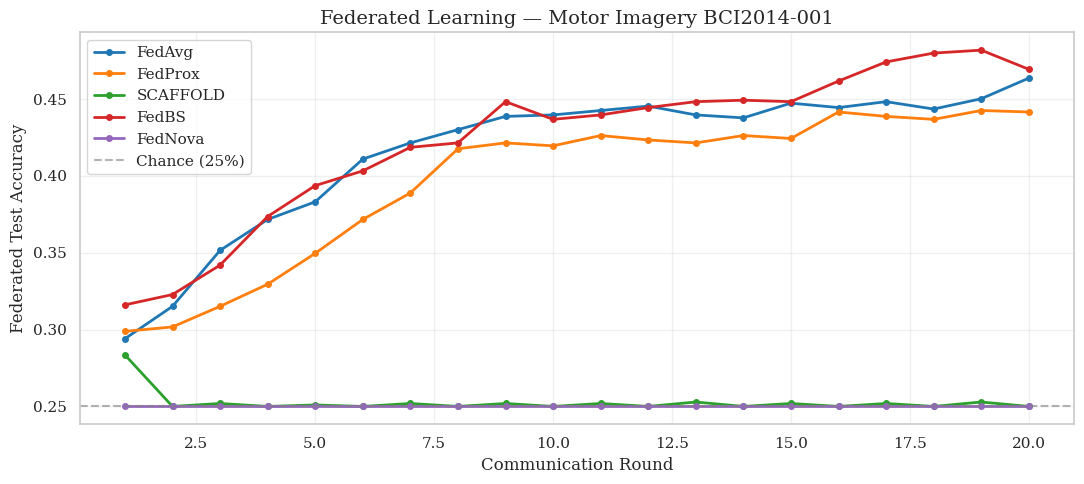

In [49]:
# 11a. Accuracy curves
pal = sns.color_palette('tab10', len(STRATEGIES))
fig, ax = plt.subplots(figsize=(11,5))
for s, c in zip(STRATEGIES, pal):
    h = all_results[s]['history']
    ax.plot([r for r,_ in h], [a for _,a in h], 'o-', ms=4, lw=2, label=s, color=c)
ax.axhline(0.25, color='grey', ls='--', alpha=.6, label='Chance (25%)')
ax.set_xlabel('Communication Round', fontsize=12)
ax.set_ylabel('Federated Test Accuracy', fontsize=12)
ax.set_title('Federated Learning — Motor Imagery BCI2014-001', fontsize=14)
ax.legend(fontsize=11); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('fl_curves.png', dpi=150); plt.show()

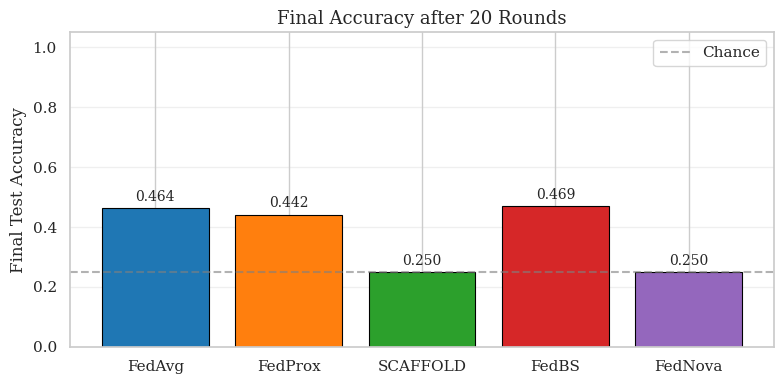

Strategy Final Acc    Best
  FedAvg    0.4636        
 FedProx    0.4416        
SCAFFOLD    0.2500        
   FedBS    0.4693 <- best
 FedNova    0.2500        


In [50]:
# 11b. Final accuracy bar
final = {s: all_results[s]['history'][-1][1] for s in STRATEGIES}
best  = max(final, key=final.get)
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(list(final.keys()), list(final.values()), color=pal, edgecolor='k', lw=.8)
ax.bar_label(bars, fmt='%.3f', fontsize=10, padding=3)
ax.axhline(0.25, color='grey', ls='--', alpha=.6, label='Chance')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Final Test Accuracy', fontsize=12)
ax.set_title(f'Final Accuracy after {CFG["num_rounds"]} Rounds', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.savefig('fl_final_acc.png', dpi=150); plt.show()
df = pd.DataFrame({'Strategy': STRATEGIES,
                   'Final Acc': [f'{final[s]:.4f}' for s in STRATEGIES],
                   'Best': ['<- best' if s==best else '' for s in STRATEGIES]})
print(df.to_string(index=False))

  Subject 01: 0.6897
  Subject 02: 0.2759
  Subject 03: 0.7155
  Subject 04: 0.4224
  Subject 05: 0.3190
  Subject 06: 0.3534
  Subject 07: 0.5086
  Subject 08: 0.5259
  Subject 09: 0.6207


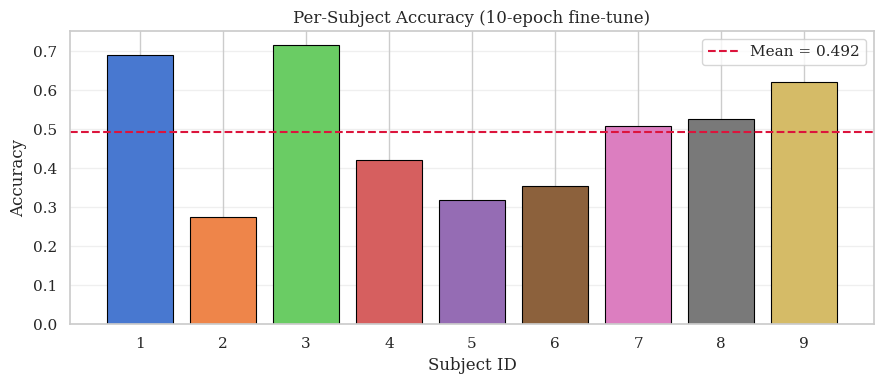

In [51]:
# 11c. Per-subject accuracy (10-epoch local fine-tune)
subj_acc = []
for cid in range(N_CLIENTS):
    m  = new_model().to(DEVICE)
    tr = make_loader(client_data[cid]['X_train'], client_data[cid]['y_train'], CFG['batch_size'])
    te = make_loader(client_data[cid]['X_test'],  client_data[cid]['y_test'],  CFG['batch_size'], shuffle=False)
    train_local(m, tr, 10, DEVICE)
    _, acc = eval_model(m, te, DEVICE)
    subj_acc.append(acc)
    print(f'  Subject {cid+1:02d}: {acc:.4f}')

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(range(1,N_CLIENTS+1), subj_acc,
       color=sns.color_palette('muted',N_CLIENTS), edgecolor='k', lw=.8)
ax.axhline(np.mean(subj_acc), color='crimson', ls='--',
           label=f'Mean = {np.mean(subj_acc):.3f}')
ax.set(xlabel='Subject ID', ylabel='Accuracy',
       title='Per-Subject Accuracy (10-epoch fine-tune)',
       xticks=range(1,N_CLIENTS+1))
ax.legend(); ax.grid(axis='y', alpha=.3)
plt.tight_layout(); plt.savefig('fl_per_subject.png', dpi=150); plt.show()

Best subject: 3  acc=0.7155


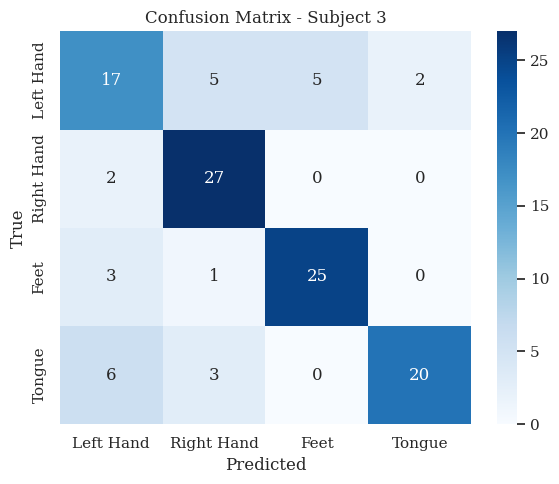

              precision    recall  f1-score   support

   Left Hand       0.61      0.59      0.60        29
  Right Hand       0.75      0.93      0.83        29
        Feet       0.83      0.86      0.85        29
      Tongue       0.91      0.69      0.78        29

    accuracy                           0.77       116
   macro avg       0.77      0.77      0.76       116
weighted avg       0.77      0.77      0.76       116



In [52]:
# 11d. Confusion matrix - best subject
bs = int(np.argmax(subj_acc))
print(f'Best subject: {bs+1}  acc={subj_acc[bs]:.4f}')
m  = new_model().to(DEVICE)
tr = make_loader(client_data[bs]['X_train'], client_data[bs]['y_train'], CFG['batch_size'])
train_local(m, tr, 15, DEVICE)
m.eval()
with torch.no_grad():
    pred = m(torch.tensor(client_data[bs]['X_test']).to(DEVICE)).argmax(1).cpu().numpy()
true = client_data[bs]['y_test']
labs = ['Left Hand','Right Hand','Feet','Tongue']
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(confusion_matrix(true,pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=labs, yticklabels=labs, ax=ax)
ax.set(xlabel='Predicted', ylabel='True', title=f'Confusion Matrix - Subject {bs+1}')
plt.tight_layout(); plt.savefig('fl_confusion.png', dpi=150); plt.show()
print(classification_report(true,pred,target_names=labs))

## 12. Summary

In [53]:
# 12. Summary
SEP = '=' * 68
desc = {'FedAvg'  : 'Weighted average of client parameters',
        'FedProx' : f'FedAvg + proximal reg  mu={CFG["proximal_mu"]}',
        'SCAFFOLD': 'Control-variate variance reduction (c_i per client)',
        'FedBS'   : 'FedAvg + class-balanced sampling (WeightedRandomSampler)',
        'FedNova' : 'Normalised averaging - update / local_steps'}
print(SEP)
print('  FEDERATED LEARNING - FINAL SUMMARY')
print(SEP)
print(f'  Dataset : BCI-IV 2a  |  Clients: {N_CLIENTS}  |  Rounds: {CFG["num_rounds"]}  |  Device: {DEVICE}')
print()
print(f'  {"Strategy":<10}  {"Acc":>8}  Description')
print(f'  {"-"*10}  {"-"*8}  {"-"*42}')
for s in STRATEGIES:
    flag = '  <- best' if s==best else ''
    print(f'  {s:<10}  {final[s]:>8.4f}  {desc[s]}{flag}')
print(f'\n  Chance (4-class): 0.2500')
print(SEP)

  FEDERATED LEARNING - FINAL SUMMARY
  Dataset : BCI-IV 2a  |  Clients: 9  |  Rounds: 20  |  Device: cuda

  Strategy         Acc  Description
  ----------  --------  ------------------------------------------
  FedAvg        0.4636  Weighted average of client parameters
  FedProx       0.4416  FedAvg + proximal reg  mu=0.01
  SCAFFOLD      0.2500  Control-variate variance reduction (c_i per client)
  FedBS         0.4693  FedAvg + class-balanced sampling (WeightedRandomSampler)  <- best
  FedNova       0.2500  Normalised averaging - update / local_steps

  Chance (4-class): 0.2500
